In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
import torch

In [3]:
names = []
with open("names.txt", 'r')  as f:
    for name in f.readlines():
        names.append(name[:-1])

In [4]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
chars = set(list(''.join(names)))
# add an additional spesial charected to mark the start and end of the name
chars.add('.')
stoi = {c:i for i,c in enumerate(sorted(chars))}
itos = {i:c for c, i in stoi.items()}

In [6]:
stoi

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
num_chars = len(chars)

In [8]:
# create the bigrams
# bigram = {}
# for name in names:
#     # pre and post pad with special charecter to mark the star and end of the word
#     name = ['.'] + list(name) + ['.']
#     for c0,c1 in zip(name[:-1], name[1:]):
#         bigram[(c0, c1)] = bigram.get((c0, c1), 0) + 1

N = torch.zeros((num_chars, num_chars), dtype = torch.int32)
for name in names:
    # pre and post pad with special charecter to mark the star and end of the word
    name = ['.'] + list(name) + ['.']
    for c0,c1 in zip(name[:-1], name[1:]):
        N[stoi[c0], stoi[c1]] += 1 


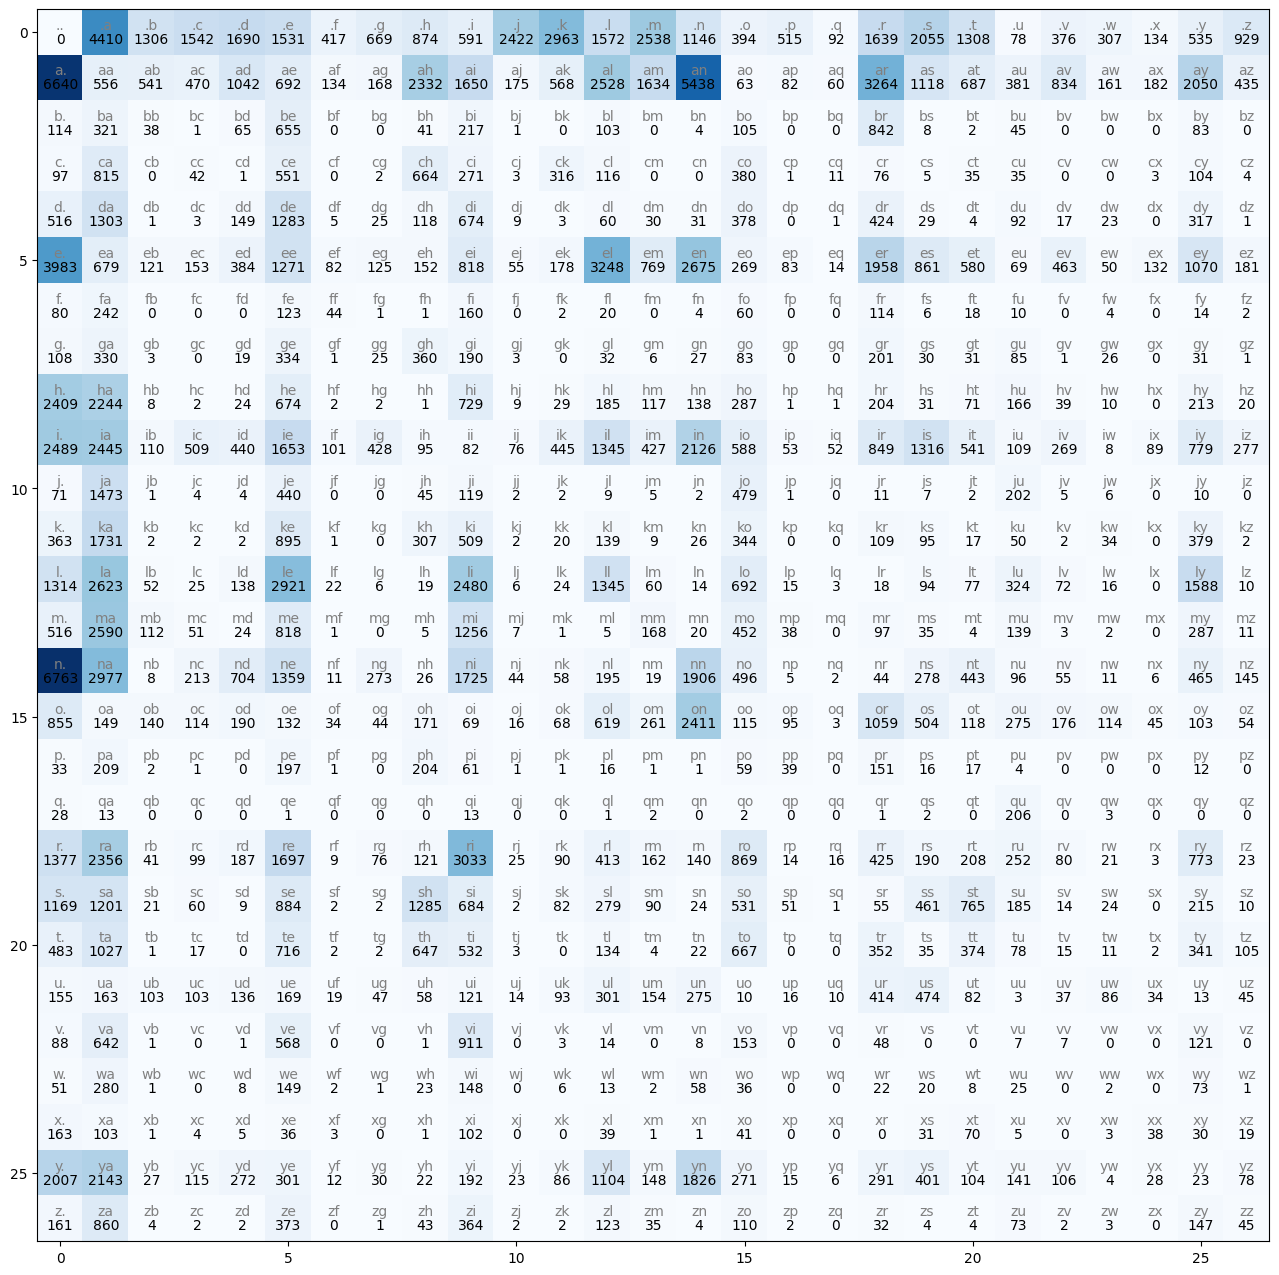

In [9]:
# plot the bigram statistic
plt.figure(figsize=(16,16))
plt.imshow(N, cmap="Blues")
for i in range(num_chars):
    for j in  range(num_chars):
        chrs = itos[i] + itos[j]
        plt.text(j, i, chrs, ha="center", va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='black')
plt.show()

In [ ]:
# calculate the probability
# add a smoothing parateter
# larger the smeething parameter more smoother probability and sharper for the lower value
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [42]:
g = torch.Generator().manual_seed(214483647)

In [69]:

# p = torch.tensor([0.1, 0.2, 0.7])
# sample = torch.multinomial(p, num_samples = 50, replacement = True, generator = g)
# sample
for i in range(10):
    idx = 0
    output = ''
    while True:
        # sample next charector given the index, from the computed probability distribution
        p = P[idx]
        sample = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        if itos[sample] == '.':
            break
        output+=itos[sample]
        idx = sample
    print(output)

a
l
ve
kyfira
male
bodegeraviemileaton
k
koha
kizza
se


In [70]:
# what is the propbibility assigned by the model to the bigrams
log_likelihood = 0
n = 0
for w in ['jq']:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w[:-1], w[1:]):
        idx1 = stoi[c1]
        idx2 = stoi[c2]
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f"{c1}{c2} : {prob:4f} {logprob:4f}") 
print(f"{log_likelihood = }")
nll = -log_likelihood/n
print(f"{nll}")

.j : 0.075577 -2.582603
jq : 0.000342 -7.981733
q. : 0.096990 -2.333148
log_likelihood = tensor(-12.8975)
4.299161434173584


In [52]:
# probility if the model assigned randomly
1/num_chars

0.037037037037037035